# Artificial Neural Network (ANN) Regression - Medical Cost Prediction

## Project Overview

This project develops an Artificial Neural Network (ANN) regression model to estimate individual medical insurance charges from demographic and lifestyle attributes. The notebook demonstrates a complete deep learning workflow, from data exploration and preprocessing to model training and evaluation.

## 1. Import Required Libraries

Import the libraries required for data manipulation, visualization, preprocessing, model development, and evaluation.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load Dataset

Load the insurance dataset and inspect the first few records to verify that it has been imported correctly.

In [15]:
df=pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Explore Dataset

Understand the dataset by examining its structure, summary statistics, missing values, and data types.

In [16]:
display(df.info())
display(df.describe())
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 4. Exploratory Data Analysis

Explore feature distributions and relationships to identify patterns that may influence medical insurance charges.

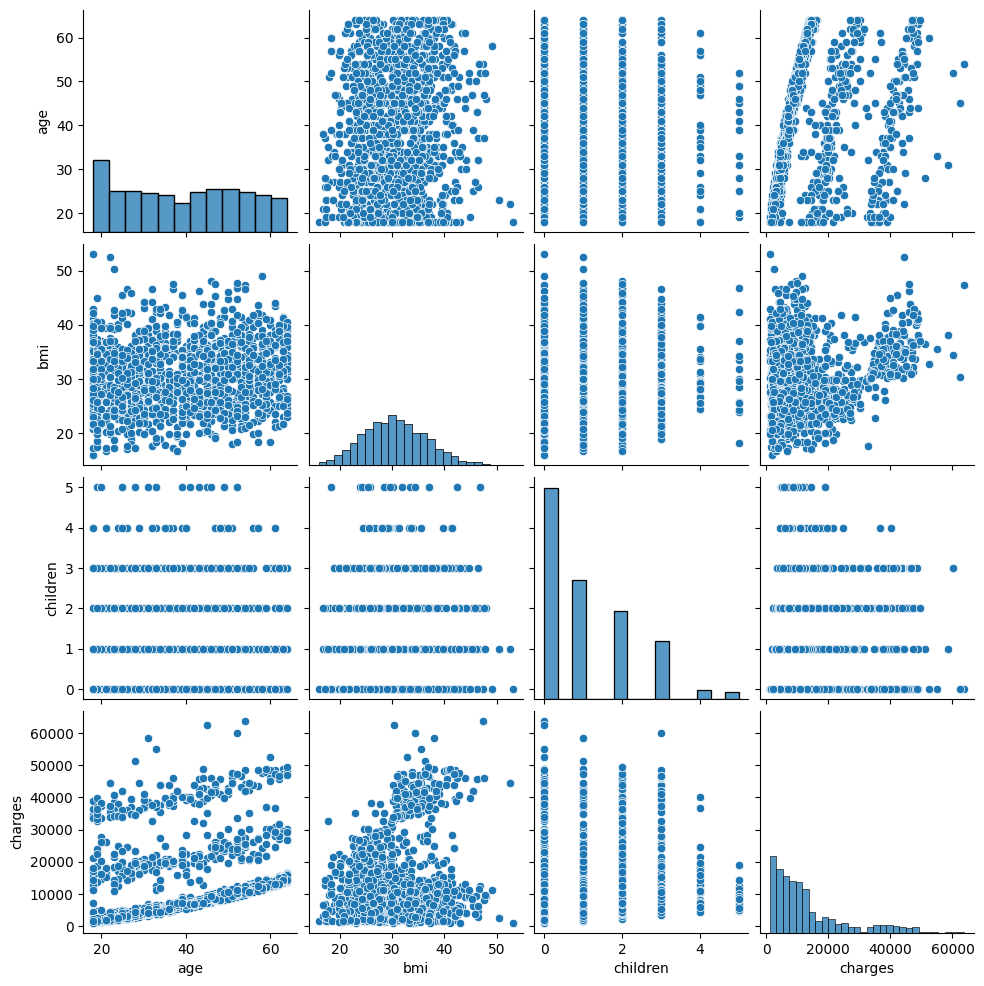

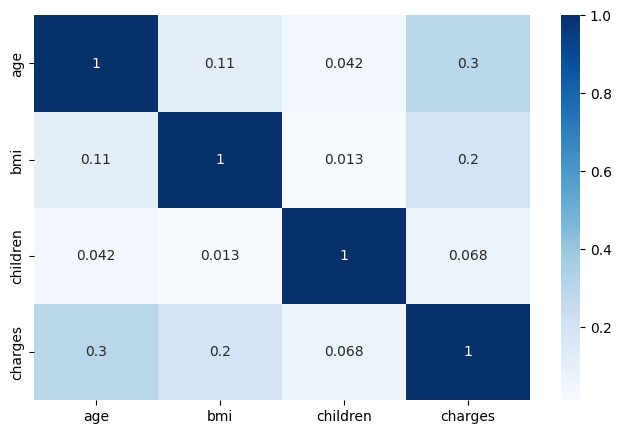

In [17]:
sns.pairplot(df[['age','bmi','children','charges']]);
plt.show()
plt.figure(figsize=(8,5));sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Blues');plt.show()

## 5. Prepare Features and Target

Separate the predictor variables from the target variable (`charges`) for model training.

In [18]:
X=df.drop('charges',axis=1)
y=df['charges']

## 6. Train, Validation, and Test Split

Split the dataset into training, validation, and test sets to ensure unbiased model evaluation.

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=0.2,random_state=42)

## 7. Feature Preprocessing

Scale numerical features and one-hot encode categorical variables using a preprocessing pipeline.

In [20]:
num=['age','bmi','children']
cat=['sex','smoker','region']
preprocessor=ColumnTransformer([('num',StandardScaler(),num),('cat',OneHotEncoder(handle_unknown='ignore'),cat)])
X_train_p=preprocessor.fit_transform(X_train)
X_val_p=preprocessor.transform(X_val)
X_test_p=preprocessor.transform(X_test)

## 8. Build Artificial Neural Network

Design a fully connected ANN architecture suitable for a regression problem.

In [21]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(X_train_p.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the Model

Train the ANN using early stopping to reduce overfitting and restore the best-performing model.

In [22]:
early=EarlyStopping(monitor='val_loss',patience=20,restore_best_weights=True)
history=model.fit(X_train_p,y_train,validation_data=(X_val_p,y_val),epochs=300,batch_size=32,callbacks=[early],verbose=1)

Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 314244672.0000 - mae: 13184.9785 - val_loss: 355174720.0000 - val_mae: 13986.9297
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 314192448.0000 - mae: 13183.0771 - val_loss: 355087392.0000 - val_mae: 13983.9717
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 314056928.0000 - mae: 13178.2754 - val_loss: 354864448.0000 - val_mae: 13976.4365
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 313750720.0000 - mae: 13166.8555 - val_loss: 354374592.0000 - val_mae: 13959.9531
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 313114816.0000 - mae: 13144.1953 - val_loss: 353468928.0000 - val_mae: 13929.6006
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 312019168.0000 - mae: 13104.4834 - val_loss: 351946848.0000 - val_mae: 13878.5977
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 310253504.0000 - mae: 13039.8193 - val_loss: 349622016.0000 - val_mae: 13800.5713
Epoch 8/300


## 10. Training and Validation Curves

Visualize the training and validation loss to assess the learning process.

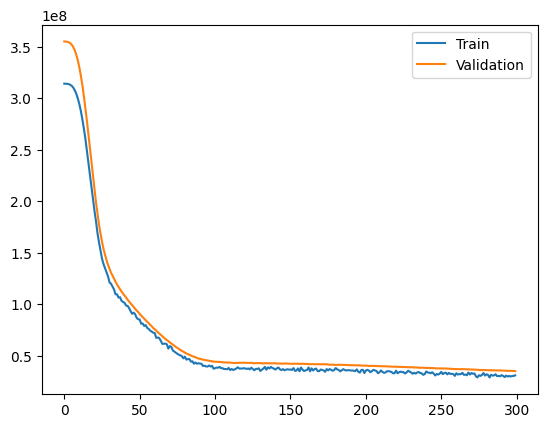

In [23]:
plt.plot(history.history['loss'],label='Train');plt.plot(history.history['val_loss'],label='Validation');plt.legend();plt.show()

## 11. Evaluate Model on Test Set

Evaluate the trained model on unseen test data using regression performance metrics.

In [24]:
pred=model.predict(X_test_p).flatten()
mae=mean_absolute_error(y_test,pred)
rmse=np.sqrt(mean_squared_error(y_test,pred))
r2=r2_score(y_test,pred)
print({'MAE':mae,'RMSE':rmse,'R2':r2})

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
{'MAE': 3245.695700604798, 'RMSE': np.float64(5025.593453002943), 'R2': 0.8373153241757446}


## 12. Actual vs Predicted

Compare predicted medical charges with actual values to assess prediction quality.

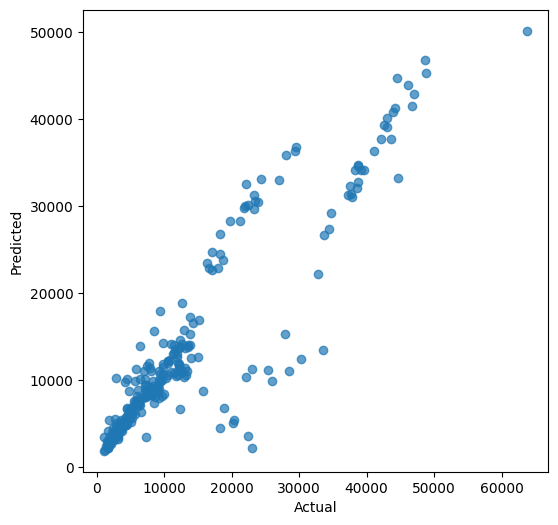

In [25]:
plt.figure(figsize=(6,6));plt.scatter(y_test,pred,alpha=0.7);plt.xlabel('Actual');plt.ylabel('Predicted');plt.show()

## 13. Residual Analysis

Analyze prediction errors to identify potential bias or systematic patterns in the model.

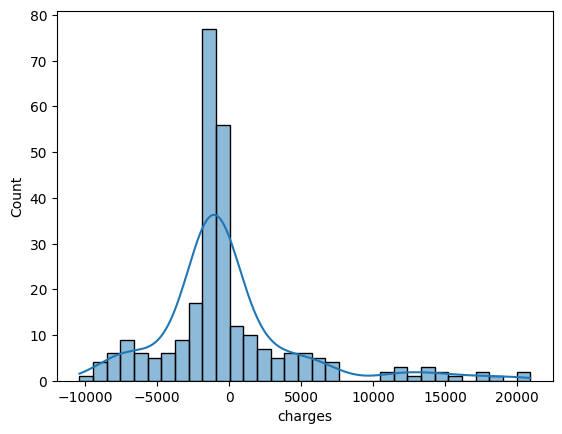

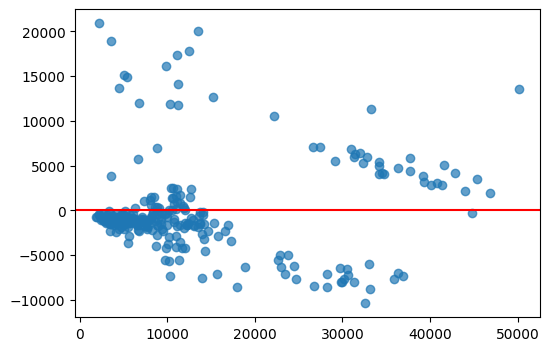

In [26]:
res=y_test-pred
sns.histplot(res,kde=True);plt.show()
plt.figure(figsize=(6,4));plt.scatter(pred,res,alpha=0.7);plt.axhline(0,color='red');plt.show()

## 14. Key Findings

- The Artificial Neural Network explained approximately **83.7%** of the variance in medical insurance charges on the test set (R² = 0.8373).
- The model achieved a **Mean Absolute Error (MAE)** of approximately **3245.70** and a **Root Mean Squared Error (RMSE)** of approximately **5025.59**.
- Training and validation loss decreased consistently and converged well, indicating stable learning without obvious overfitting.
- The model captured the overall relationship between customer attributes and insurance charges, although prediction errors remained larger for some high-cost cases.

## 15. Conclusion

This project demonstrates the application of an Artificial Neural Network (ANN) for a structured regression problem involving medical insurance cost prediction. The model achieved strong predictive performance on unseen test data, explaining approximately 84% of the variation in insurance charges. By combining appropriate preprocessing, validation-based early stopping, and multiple regression evaluation metrics, the project provides a reliable and reproducible deep learning workflow suitable for portfolio presentation.